In [108]:
def pq2tfmatrix(pq):
  import meshcat.transformations as tf
  import numpy as np
  """
  Convert a pq to a transformation matrix
  :param pq: [position, quaternion]
  :return: transformation matrix
  """
  p = pq[:3]
  q = pq[3:]
  q.insert(0, q.pop())
  return tf.quaternion_matrix(q) + np.array([[0, 0, 0, p[0]],
                                             [0, 0, 0, p[1]],
                                             [0, 0, 0, p[2]],
                                             [0, 0, 0, 0]])
    
def robotInit(numLinks, resource_path, displayInitJson, vis):
  import meshcat.geometry as g
  import numpy as np
  robot = vis['robot']
  partInitConfig = displayInitJson['part_init_config']
  for i in range(numLinks):
    robot[str(i)].set_transform(pq2tfmatrix(partInitConfig[i]))

  geometryPool = displayInitJson['geometry_pool']
  for i in range(len(geometryPool)):
    geometry = geometryPool[i]
    meshcatGeo = robot[str(geometry['part_id'])][str(geometry['geometry_id'])]
    meshcatGeo.set_transform(np.array(geometry['init_pm']).reshape(4, 4))
    if i % 2 == 1: 
      material = g.MeshPhongMaterial(color=0x0660FF)
    else:
      material = g.MeshPhongMaterial(color=0xD4D4D4)
    if i == 0:
      material = g.MeshPhongMaterial(color=0x755338)
    if(geometry['shape_type'] == 'box'):
      meshcatGeo.set_object(g.Box([geometry['length'], geometry['width'], geometry['height']]), material=material)
    elif(geometry['shape_type'] == 'capsule'):
      meshcatGeo.set_object(g.Cylinder(geometry['size'][0], geometry['size'][1]), material=material)
    elif(geometry['shape_type'] == 'sphere'):
      meshcatGeo.set_object(g.Sphere(geometry['radius']), material=material)
    elif(geometry['shape_type'] == 'mesh'):
      ext = geometry['resource_path'].split('.')[-1]
      if ext == 'stl':
        meshcatGeo.set_object(g.StlMeshGeometry.from_file(
          resource_path, geometry['resource_path']), material=material)
      elif ext == 'obj':
        meshcatGeo.set_object(g.ObjMeshGeometry.from_file(
          resource_path + geometry['resource_path']), material=material)
      else:
        print("Unknown mesh file type", ext)

def setRobotPq(numLinks, frame, pqs):
  robot = frame['robot']
  for i in range(numLinks):
    robot[str(i)].set_transform(pq2tfmatrix(pqs[i]))

def binarySearch(timeIndices, time):
  import math
  """
  Binary search to find the index of the closest time
  :param timeIndices: list of time indices
  :param time: target time
  :return: index of the closest time index
  """
  low = 0
  high = len(timeIndices) - 1
  while low <= high:
    mid = (low + high) // 2
    if math.isclose(timeIndices[mid], time):
      return mid
    if timeIndices[mid] < time:
      low = mid + 1
    else:
      high = mid - 1

  return min(int(low), len(timeIndices) - 1)

def animateRobotByRecords(numLinks, records, frameRate, vis):
  from meshcat.animation import Animation
  partpq = records['partPq']
  timeIndices = records['timeIndex']
  anim = Animation()
  anim.default_framerate = frameRate

  minTime = 0
  maxTime = timeIndices[-1]
  totalFrameNumber = int((maxTime - minTime) * anim.default_framerate)

  for i in range(totalFrameNumber):
    currentTime = minTime + i / anim.default_framerate
    currentIdx = binarySearch(timeIndices, currentTime)
    with anim.at_frame(vis, i) as frame:
      setRobotPq(numLinks, frame, partpq[currentIdx])

  vis.set_animation(anim)

In [109]:
import sys
# sys.path.append("D:/code/sire/install/python/release")
import sire

In [110]:
from os.path import abspath
import os
cs = sire.ControlServer.instance()
print(abspath(os.getcwd()) + "/sire_ball_free_fall.xml")
sire.fromXmlFile(cs, abspath(os.getcwd()) + "/sire_ball_free_fall.xml")
cs.init()
print(sire.toXmlString(cs))

d:\code\sire\demo\demo_python/sire_ball_free_fall.xml
<ControlServer>
    <Model __prop_name__="model" name="FreeFallModel" time="0">
        <Environment __prop_name__="environment" gravity="{0,0,-9.8,0,0,0}"/>
        <VariablePoolElement __prop_name__="variable_pool">
            <MatrixVariable name="tool0_pe">{0,0,0,0,0,0}</MatrixVariable>
            <StringVariable name="tool0_pe_type">321</StringVariable>
            <MatrixVariable name="base_pe">{0,0,0,0,0,0}</MatrixVariable>
            <StringVariable name="base_pe_type">321</StringVariable>
        </VariablePoolElement>
        <PartPoolElement __prop_name__="part_pool">
            <Part name="ground" active="true" pe="{0,0,0,-0,0,-0}" vel="{0,0,0,0,0,0}" acc="{0,0,0,0,0,0}" inertia="{1,0,0,0,1,1,1,0,0,0}">
                <MarkerPoolElement __prop_name__="marker_pool">
                    <Marker name="joint_0_j" active="true" pe="{0,0,0,0,0,-0}"/>
                    <Marker name="ground" active="true" pe="{0,0,0,0,0,-

In [111]:
simulator = sire.simulator(cs)
while(not simulator.isTimeout() and not simulator.isEventListEmpty()):
  simulator.step(1, False)
  # print("Simulation time", simulator.simTime())

In [112]:
model = cs.model()
displayInitJson = model.displayInitJson()
result = simulator.recordsToJson()

In [113]:
import meshcat
displayInitJson
vis = meshcat.Visualizer()
resourcePath = "D:/code/sire/web_interface/public"
robotInit(model.numLinks(), resourcePath, displayInitJson, vis)
animateRobotByRecords(model.numLinks(), result, 1000, vis)
vis.jupyter_cell()

You can open the visualizer by visiting the following URL:
http://127.0.0.1:7010/static/


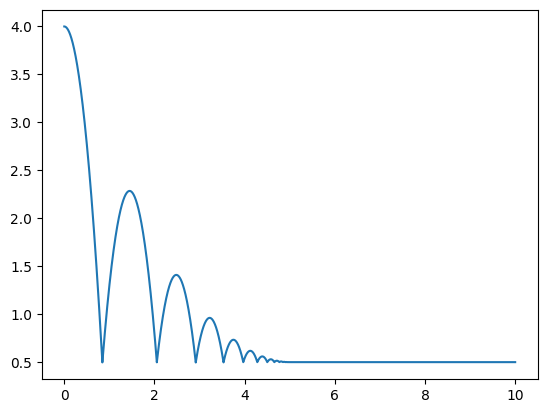

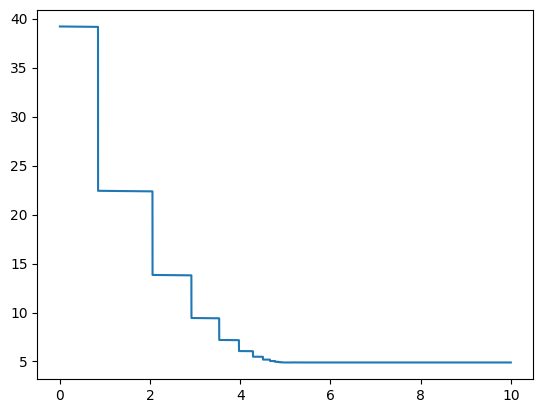

(np.int64(1450), np.float64(2.2852934054218825))
(np.int64(2486), np.float64(1.409711118814793))
(np.int64(4131), np.float64(0.6182286851941148))
(np.int64(6052), np.float64(0.4999968117295437))
(np.int64(8052), np.float64(0.4999968117295437))


In [114]:
import matplotlib.pyplot as plt
import numpy as np
timeIndices = result['timeIndex']
contactInfo = result["contactInfo"]
partpq = result["partPq"]
partvs = result["partVs"]
partas = result["partAs"]
dts = result["dts"]
x = []
y = []
yv = []

lowerBound = binarySearch(timeIndices, 0)
upperBound = binarySearch(timeIndices, 10)

for i in range(lowerBound, upperBound + 1):
  # print(i, timeIndices[i], dts[i], partpq[i][1], partvs[i][1], partas[i][1], contactInfo[i])
  x.append(timeIndices[i])
  y.append(pq2tfmatrix(partpq[i][1])[2, 3])  # z position from transformation matrix
  yv.append(partvs[i][1][2])  # z velocity
plt.plot(x, y)
plt.savefig("D:/papers/sire_contact_model/res/sphere_free_fall_height_data2.pdf", format="pdf")
plt.show()

def calculate_energy(m, height, velocity, g):
    return m * g * height + 0.5 * m * velocity * velocity 

def replace_smaller_with_previous(lst, threshold):
    """
    将列表中所有小于threshold的值替换为前一个元素的值
    第一个元素没有前一个元素，保持不变
    """
    if not lst:  # 处理空列表
        return lst
    
    result = lst.copy()  # 创建列表的副本，避免修改原列表
    
    for i in range(1, len(result)):
        if result[i] < threshold:
            result[i] = result[i-1]
    
    return result

energyList = []
for i in range(lowerBound, upperBound + 1):
  energyList.append(calculate_energy(1.0, y[i - lowerBound], yv[i - lowerBound], 9.8))

energy = replace_smaller_with_previous(energyList, -1)

plt.plot(x, energy)
plt.show()

def findMaxHeightAtRange(x, minTime, maxTime):
  idx_t0 = min(range(len(x)), key=lambda i: abs(x[i] - minTime))
  idx_t1 = min(range(len(x)), key=lambda i: abs(x[i] - maxTime))
  height1Idx = np.argmax(y[idx_t0:idx_t1])
  return (height1Idx+idx_t0, y[height1Idx+idx_t0])

print(findMaxHeightAtRange(x, 1, 2))
print(findMaxHeightAtRange(x, 2, 4))
print(findMaxHeightAtRange(x, 4, 6))
print(findMaxHeightAtRange(x, 6, 7))
print(findMaxHeightAtRange(x, 8, 9))

In [115]:
currentIdx = 4015
print(currentIdx, timeIndices[currentIdx], dts[currentIdx], partpq[currentIdx][1], partvs[currentIdx][1], partas[currentIdx][1], contactInfo[currentIdx])
currentIdx = binarySearch(result["timeIndex"], 4.0052)
print(currentIdx, timeIndices[currentIdx], dts[currentIdx], partpq[currentIdx][1], partvs[currentIdx][1], partas[currentIdx][1], contactInfo[currentIdx])
currentIdx = binarySearch(result["timeIndex"], 4.00525)
print(currentIdx, timeIndices[currentIdx], dts[currentIdx], partpq[currentIdx][1], partvs[currentIdx][1], partas[currentIdx][1], contactInfo[currentIdx])


4015 4.009999999999674 0.001000000000000334 [0.0, 0.0, 0.5527625062699665, 0.0, 0.0, 0.0, 1.0] [0.0, 0.0, 1.1376636114150742, 0.0, 0.0, 0.0] [0.0, 0.0, -9.8, -0.0, -0.0, -0.0] None
4011 4.0059999999996725 0.001000000000000334 [0.0, 0.0, 0.5481530518243046, 0.0, 0.0, 0.0, 1.0] [0.0, 0.0, 1.1768636114150877, 0.0, 0.0, 0.0] [0.0, 0.0, -9.8, -0.0, -0.0, -0.0] None
4011 4.0059999999996725 0.001000000000000334 [0.0, 0.0, 0.5481530518243046, 0.0, 0.0, 0.0, 1.0] [0.0, 0.0, 1.1768636114150877, 0.0, 0.0, 0.0] [0.0, 0.0, -9.8, -0.0, -0.0, -0.0] None


In [116]:
# 4.190999999999734 [0.0, 0.0, 1.0000021810337338, 0.0, 0.0, 0.0, 1.0] [0.0, 0.0, -0.002929150576415091, 0.0, 0.0, 0.0] [-0.0, -0.0, -9.8, 0.0, 0.0, -0.0] None
# 4.191999999999735 [0.0, 0.0, 0.9999894518831575, 0.0, 0.0, 0.0, 1.0] [0.0, 0.0, -0.012729150576418364, 0.0, 0.0, 0.0] [0.0, 0.0, 87.49722059997538, -0.0, -0.0, -0.0] [{'contactForce': [-0.0, 0.0, 97.29722059997538], 'contactWrench': [-0.0, 0.0, 97.29722059997538, 0.0, -0.0, 0.0], 'contact_point_pe': [0.0, 0.0, 0.49999472594157873, 2.356194490192345, 0.0, 5.497787143782138], 'partId_A': 0, 'partId_B': 1, 'point_pair': {'depth': 0.0, 'geomIdA': 0, 'geomIdB': 1}, 'separation_speed': 0.0, 'slip_speed': 0.0}]
# 4.192999999999735 [0.0, 0.0, 0.9999914954560379, 0.0, 0.0, 0.0, 1.0] [0.0, 0.0, 0.00028451290447994385, 0.0, 0.0, 0.0] [0.0, 0.0, -9.8, -0.0, -0.0, -0.0] [{'contactForce': [-0.0, 0.0, 0.0], 'contactWrench': [-0.0, 0.0, 0.0, 0.0, -0.0, 0.0], 'contact_point_pe': [0.0, 0.0, 0.49999574772801897, 2.356194490192345, 0.0, 5.497787143782138], 'partId_A': 0, 'partId_B': 1, 'point_pair': {'depth': -2.1780204040311446e-07, 'geomIdA': 0, 'geomIdB': 1}, 'separation_speed': 0.0, 'slip_speed': 0.0}]
# 4.193999999999735 [0.0, 0.0, 0.9999819799689424, 0.0, 0.0, 0.0, 1.0] [0.0, 0.0, -0.009515487095523328, 0.0, 0.0, 0.0] [0.0, 0.0, 895.3468337893621, -0.0, -0.0, -0.0] [{'contactForce': [-0.0, 0.0, 905.1468337893621], 'contactWrench': [-0.0, 0.0, 905.1468337893621, 0.0, -0.0, 0.0], 'contact_point_pe': [0.0, 0.0, 0.4999909899844712, 2.356194490192345, 0.0, 5.497787143782138], 'partId_A': 0, 'partId_B': 1, 'point_pair': {'depth': 9.515487095490549e-06, 'geomIdA': 0, 'geomIdB': 1}, 'separation_speed': 0.0, 'slip_speed': 0.0}]
